In [1]:
%reload_ext autoreload
%autoreload 2

import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from tqdm import tqdm

import numpy as np

import pickle
from matplotlib import pyplot as plt

## 基于图像预处理的对抗样本防御

- 在前两周的实验中，你已经实现了简单的单步对抗攻击（FGSM）和迭代对抗攻击（PGD）；

- 在本周的实验中，请实现几种基于**图像预处理**技术的对抗样本防御方法，并测试它们对FGSM、PGD攻击的防御效果；

- 图像预处理防御的核心思想：在将输入送入模型之前，先对输入图像做变换（平滑、量化等），以消除或削弱对抗扰动，同时尽量保留原始语义信息；

- 具体实验步骤如下：

  1. 将代码文件（Python文件与Notebook文件）上传到服务器端根目录；

  2. 将样本数据（Week567_img_label.pkl）上传至服务器端data/目录下；

  3. 将之前训练的模型参数（lenet5.pt）上传至服务器端model/目录下；

  4. 依照提示，完成**Notebook文件**中的TODO内容；

- 本实验需要实现以下两种预处理防御方法：

  | 方法 | 函数签名 | 原理 |
  |------|----------|------|
  | 中值滤波 | `median_smooth(imgs, kernel_size)` | 用滑动窗口内像素的中值替代中心像素，去除脉冲式噪声 |
  | 位深度缩减 | `bit_depth_reduce(imgs, depth)` | 降低像素表示精度以消除细微扰动 |

In [2]:
from Week567_General_Code_Question import LeNet5, fgsm, pgd
from Week567_General_Code_Question import evaluate

In [3]:
# Parameter
# epsilon = 0.2
# alpha = 0.07
# iter = 5
# TODO：暂时先按下方的参数进行实验；完成本task后，探索最下方的“思考”，即，把参数换为上方注释掉的参数
epsilon = 0.15
alpha = 0.05
iter = 5

In [4]:
# Model
model = LeNet5()
model.load_state_dict(torch.load('model/lenet5.pt'))
model.eval()

criterion = nn.CrossEntropyLoss()

### 加载测试数据与生成对抗样本

In [5]:
with open('data/Week567_img_label.pkl', 'rb') as f:
    data = pickle.load(f)
    imgs, labels = data['img'], data['label']

In [6]:
fgsm_imgs = fgsm(imgs, epsilon, model, criterion, labels)
pgd_imgs = pgd(imgs, epsilon, alpha, iter, model, criterion, labels)

### 评测原始模型在对抗样本上的表现（基线）

In [7]:
print("Benign (clean images):")
_ = evaluate(imgs, labels, model)

print("\nAgainst FGSM:")
_ = evaluate(fgsm_imgs, labels, model)

print("\nAgainst PGD:")
_ = evaluate(pgd_imgs, labels, model)

Benign (clean images):
match rate: 1.0

Against FGSM:
match rate: 0.35

Against PGD:
match rate: 0.2


### 实现图像预处理防御函数

请在下面的代码块中实现两种图像预处理防御函数：

1. **中值滤波** `median_smooth(imgs, kernel_size)`
   - 对输入图像施加中值滤波以去除脉冲式噪声
   - 手动实现：通过双重循环遍历每个像素位置，提取 `kernel_size × kernel_size` 的邻域窗口，展平后取中值
   - 注意边界处理：只处理有完整窗口的像素（即跳过边缘 `pad` 个像素）
   - 参考文档：[Tensor.median](https://pytorch.org/docs/stable/generated/torch.Tensor.median.html)

2. **位深度缩减** `bit_depth_reduce(imgs, depth)`
   - 将像素值映射到 `[0, 2^depth - 1]` 的整数范围，四舍五入后再映射回 `[0, 1]`
   - 例如 `depth=1` 时只有 0/1 两种取值（二值化），`depth=4` 时有 16 种取值
   - 参考文档：[torch.round](https://pytorch.org/docs/stable/generated/torch.round.html)

In [8]:
def median_smooth(imgs, kernel_size=3):
    """
    基于手动循环滑窗的中值滤波实现
    imgs: [B, C, H, W] tensor
    kernel_size: 必须为奇数 (如 3, 5)
    """
    B, C, H, W = imgs.shape
    pad = kernel_size // 2
    smoothed = torch.zeros_like(imgs)
    for i in range(pad, H - pad):
        for j in range(pad, W - pad):
            roi = imgs[:, :, i - pad : i + pad + 1, j - pad : j + pad + 1]  # roi 的形状为 [B, C, kernel_size, kernel_size]
            # TODO：对变量roi进行计算，并将结果赋值给smoothed[:, :, i, j]
            # 由于kernel区域内存不连续， 无法使用view，只能使用reshape展平
            roi_flat = roi.reshape(B, C, -1)  # 将roi展平为[B, C, kernel_size*kernel_size]
            
            smoothed[:, :, i, j] = torch.median(roi_flat, dim=-1).values  # 计算中值并赋值给smoothed[:, :, i, j]
    return smoothed



def bit_depth_reduce(imgs, depth=4):
    """
    对输入图像进行位深度缩减
    imgs: [B, C, H, W] tensor, 值域 [0, 1]
    depth: 目标位深度
    return: 位深度缩减后的图像张量
    """
    max_val = 2 ** depth - 1

    # TODO: 将像素值映射到 [0, max_val]，四舍五入取整，再映射回 [0, 1]
    reduced = torch.round(imgs * max_val) / max_val

    return reduced

### 评测各预处理防御效果

In [16]:
print("=" * 60)
print("各预处理防御方法在正常样本与对抗样本上的表现")
print("=" * 60)

# --- Baseline ---
print("\n[Baseline] No defense:")
print("  Clean:", end=" ")
_ = evaluate(imgs, labels, model)
print("  Against FGSM:", end=" ")
_ = evaluate(fgsm_imgs, labels, model)
print("  Against PGD:", end=" ")
_ = evaluate(pgd_imgs, labels, model)

# --- Median Smoothing ---
print("\n[Median Smoothing] kernel_size=3:")
print("  Clean:", end=" ")
_ = evaluate(median_smooth(imgs, 3), labels, model)
print("  Against FGSM:", end=" ")
md_fgsm = median_smooth(fgsm_imgs, 3)
_ = evaluate(md_fgsm, labels, model)
print("  Against PGD:", end=" ")
md_pgd = median_smooth(pgd_imgs, 3)
_ = evaluate(md_pgd, labels, model)

# --- Bit Depth Reduction ---
print("\n[Bit Depth Reduction] depth=2:")
print("  Clean:", end=" ")
_ = evaluate(bit_depth_reduce(imgs, 2), labels, model)
print("  Against FGSM:", end=" ")
bit_fgsm = bit_depth_reduce(fgsm_imgs, 2)
_ = evaluate(bit_fgsm, labels, model)
print("  Against PGD:", end=" ")
bit_pgd = bit_depth_reduce(pgd_imgs, 2)
_ = evaluate(bit_pgd, labels, model)

各预处理防御方法在正常样本与对抗样本上的表现

[Baseline] No defense:
  Clean: match rate: 1.0
  Against FGSM: match rate: 0.35
  Against PGD: match rate: 0.2

[Median Smoothing] kernel_size=3:
  Clean: match rate: 1.0
  Against FGSM: match rate: 0.35
  Against PGD: match rate: 0.25

[Bit Depth Reduction] depth=2:
  Clean: match rate: 1.0
  Against FGSM: match rate: 0.95
  Against PGD: match rate: 0.95


### 调参实验

- 尝试不同的参数组合，观察防御效果与正常样本准确率之间的权衡
  - 中值滤波：`kernel_size` $\in$ `[3, 5, 7]`
  - 位深度缩减：`depth` $\in$ `[1, 2, 3, 4]`

In [17]:
# Median Smoothing
for ks in [3, 5, 7]:
    print(f"\n[Median] kernel_size={ks}:")
    print("  Clean:", end=" ")
    _ = evaluate(median_smooth(imgs, ks), labels, model)
    print("  FGSM:", end=" ")
    _ = evaluate(median_smooth(fgsm_imgs, ks), labels, model)
    print("  PGD:", end=" ")
    _ = evaluate(median_smooth(pgd_imgs, ks), labels, model)

# Bit Depth Reduction
for d in [1, 2, 3, 4]:
    print(f"\n[Bit Depth] depth={d}:")
    print("  Clean:", end=" ")
    _ = evaluate(bit_depth_reduce(imgs, d), labels, model)
    print("  FGSM:", end=" ")
    _ = evaluate(bit_depth_reduce(fgsm_imgs, d), labels, model)
    print("  PGD:", end=" ")
    _ = evaluate(bit_depth_reduce(pgd_imgs, d), labels, model)


[Median] kernel_size=3:
  Clean: match rate: 1.0
  FGSM: match rate: 0.35
  PGD: match rate: 0.25

[Median] kernel_size=5:
  Clean: match rate: 0.8
  FGSM: match rate: 0.1
  PGD: match rate: 0.1

[Median] kernel_size=7:
  Clean: match rate: 0.6
  FGSM: match rate: 0.05
  PGD: match rate: 0.0

[Bit Depth] depth=1:
  Clean: match rate: 1.0
  FGSM: match rate: 0.95
  PGD: match rate: 0.95

[Bit Depth] depth=2:
  Clean: match rate: 1.0
  FGSM: match rate: 0.95
  PGD: match rate: 0.95

[Bit Depth] depth=3:
  Clean: match rate: 1.0
  FGSM: match rate: 0.35
  PGD: match rate: 0.3

[Bit Depth] depth=4:
  Clean: match rate: 1.0
  FGSM: match rate: 0.35
  PGD: match rate: 0.35


### 可视化预处理效果

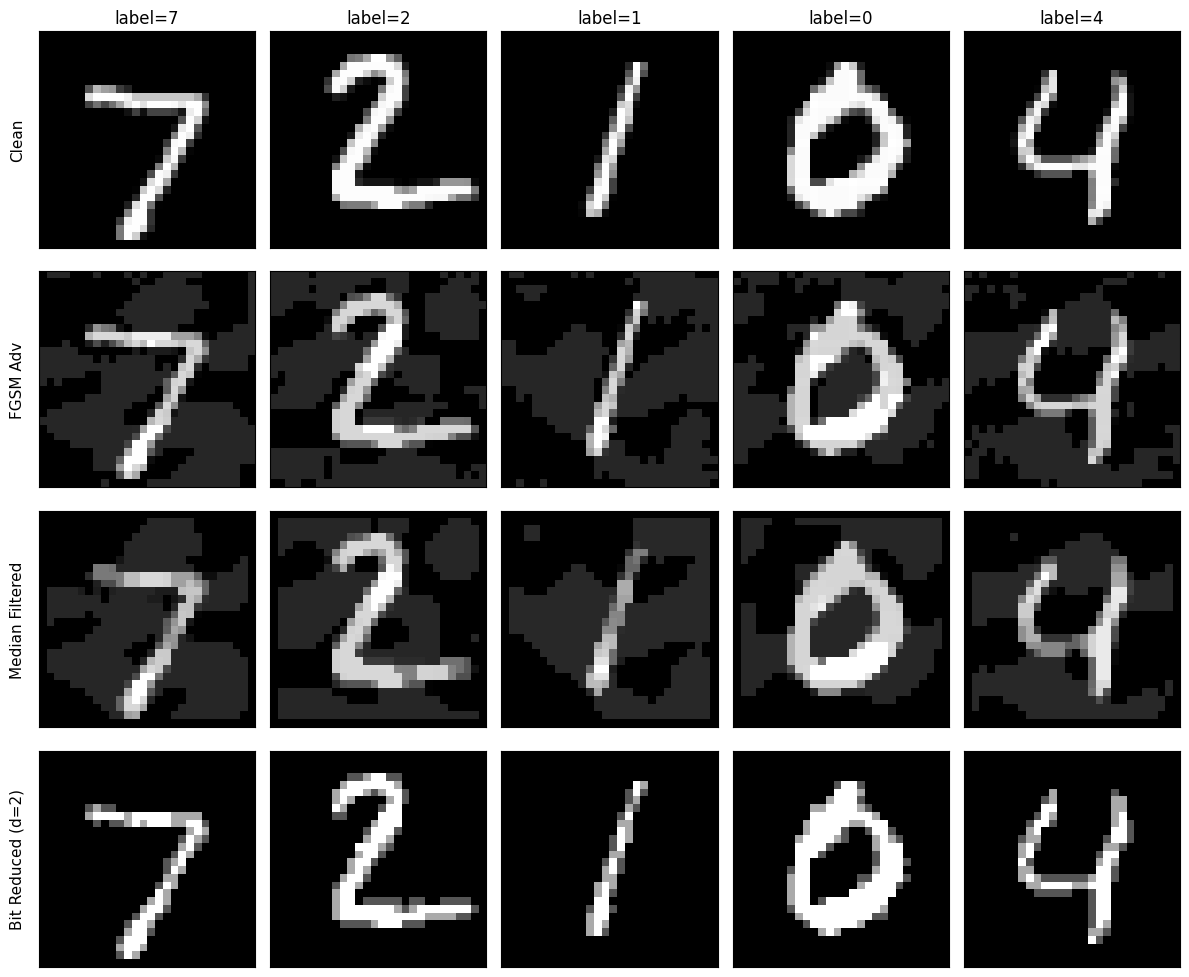

In [18]:
n_show = 5
fig, axes = plt.subplots(4, n_show, figsize=(12, 10))

row_titles = ['Clean', 'FGSM Adv', 'Median Filtered', 'Bit Reduced (d=2)']

for i in range(n_show):
    axes[0, i].imshow(imgs[i, 0].detach().numpy(), cmap='gray')
    axes[0, i].set_title(f'label={labels[i].item()}')

    axes[1, i].imshow(fgsm_imgs[i, 0].detach().numpy(), cmap='gray')

    axes[2, i].imshow(md_fgsm[i, 0].detach().numpy(), cmap='gray')

    axes[3, i].imshow(bit_fgsm[i, 0].detach().numpy(), cmap='gray')

for ax_row, title in zip(axes, row_titles):
    ax_row[0].set_ylabel(title, fontsize=11, rotation=90, labelpad=10)

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

### 思考：更强攻击下的防御效果

- 上面的实验使用了较温和的攻击参数（`epsilon=0.15, alpha=0.05`），预处理防御展现出了一定的鲁棒性提升；
- **试一试**：将上方超参数 Cell 中的注释取消，切换为更强的攻击参数（`epsilon=0.2, alpha=0.07`），重新运行所有 Cell，观察防御效果的变化；
- 思考：为什么基于图像预处理的防御方法在面对更强攻击时效果有限？如何才能从根本上提升模型的鲁棒性？—— 请继续完成 **Task 2** 中的对抗训练实验。